## 1. Dataset Loading

In [17]:
import geopandas as gpd
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
#We use the Thailand dataset provided by ADB, use AnalysisStatus valid rows for whole analysis.
thai = gpd.read_file('/content/ADB_Innovation_Thailand.geojson')
thai_filter = thai[thai['AnalysisStatus'] == "Valid"]
#PercentOverLimit' to be shown as %
thai_filter['PercentOverLimit'] = thai_filter['PercentOverLimit'] * 100

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


## 2. EDA for Non-Copmiance Evaluation

In [20]:
speed_col = 'SpeedLimit'

def categorize_speed(speed):
    if speed < 50:
        return "less than 50"
    elif 50 <= speed < 60:
        return "50-60 (60 not incl.)"
    elif 60 <= speed < 70:
        return "60-70 (70 not incl.)"
    elif 70 <= speed < 80:
        return "70-80 (80 not incl.)"
    elif 80 <= speed < 90:
        return "80-90 (90 not incl.)"
    elif 90 <= speed < 100:
        return "90-100 (100 not incl.)"
    elif 100 <= speed < 120:
        return "100-120 (120 not incl.)"
    elif speed >= 120:
        return "120 and above"
    else:
        return "Other"

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


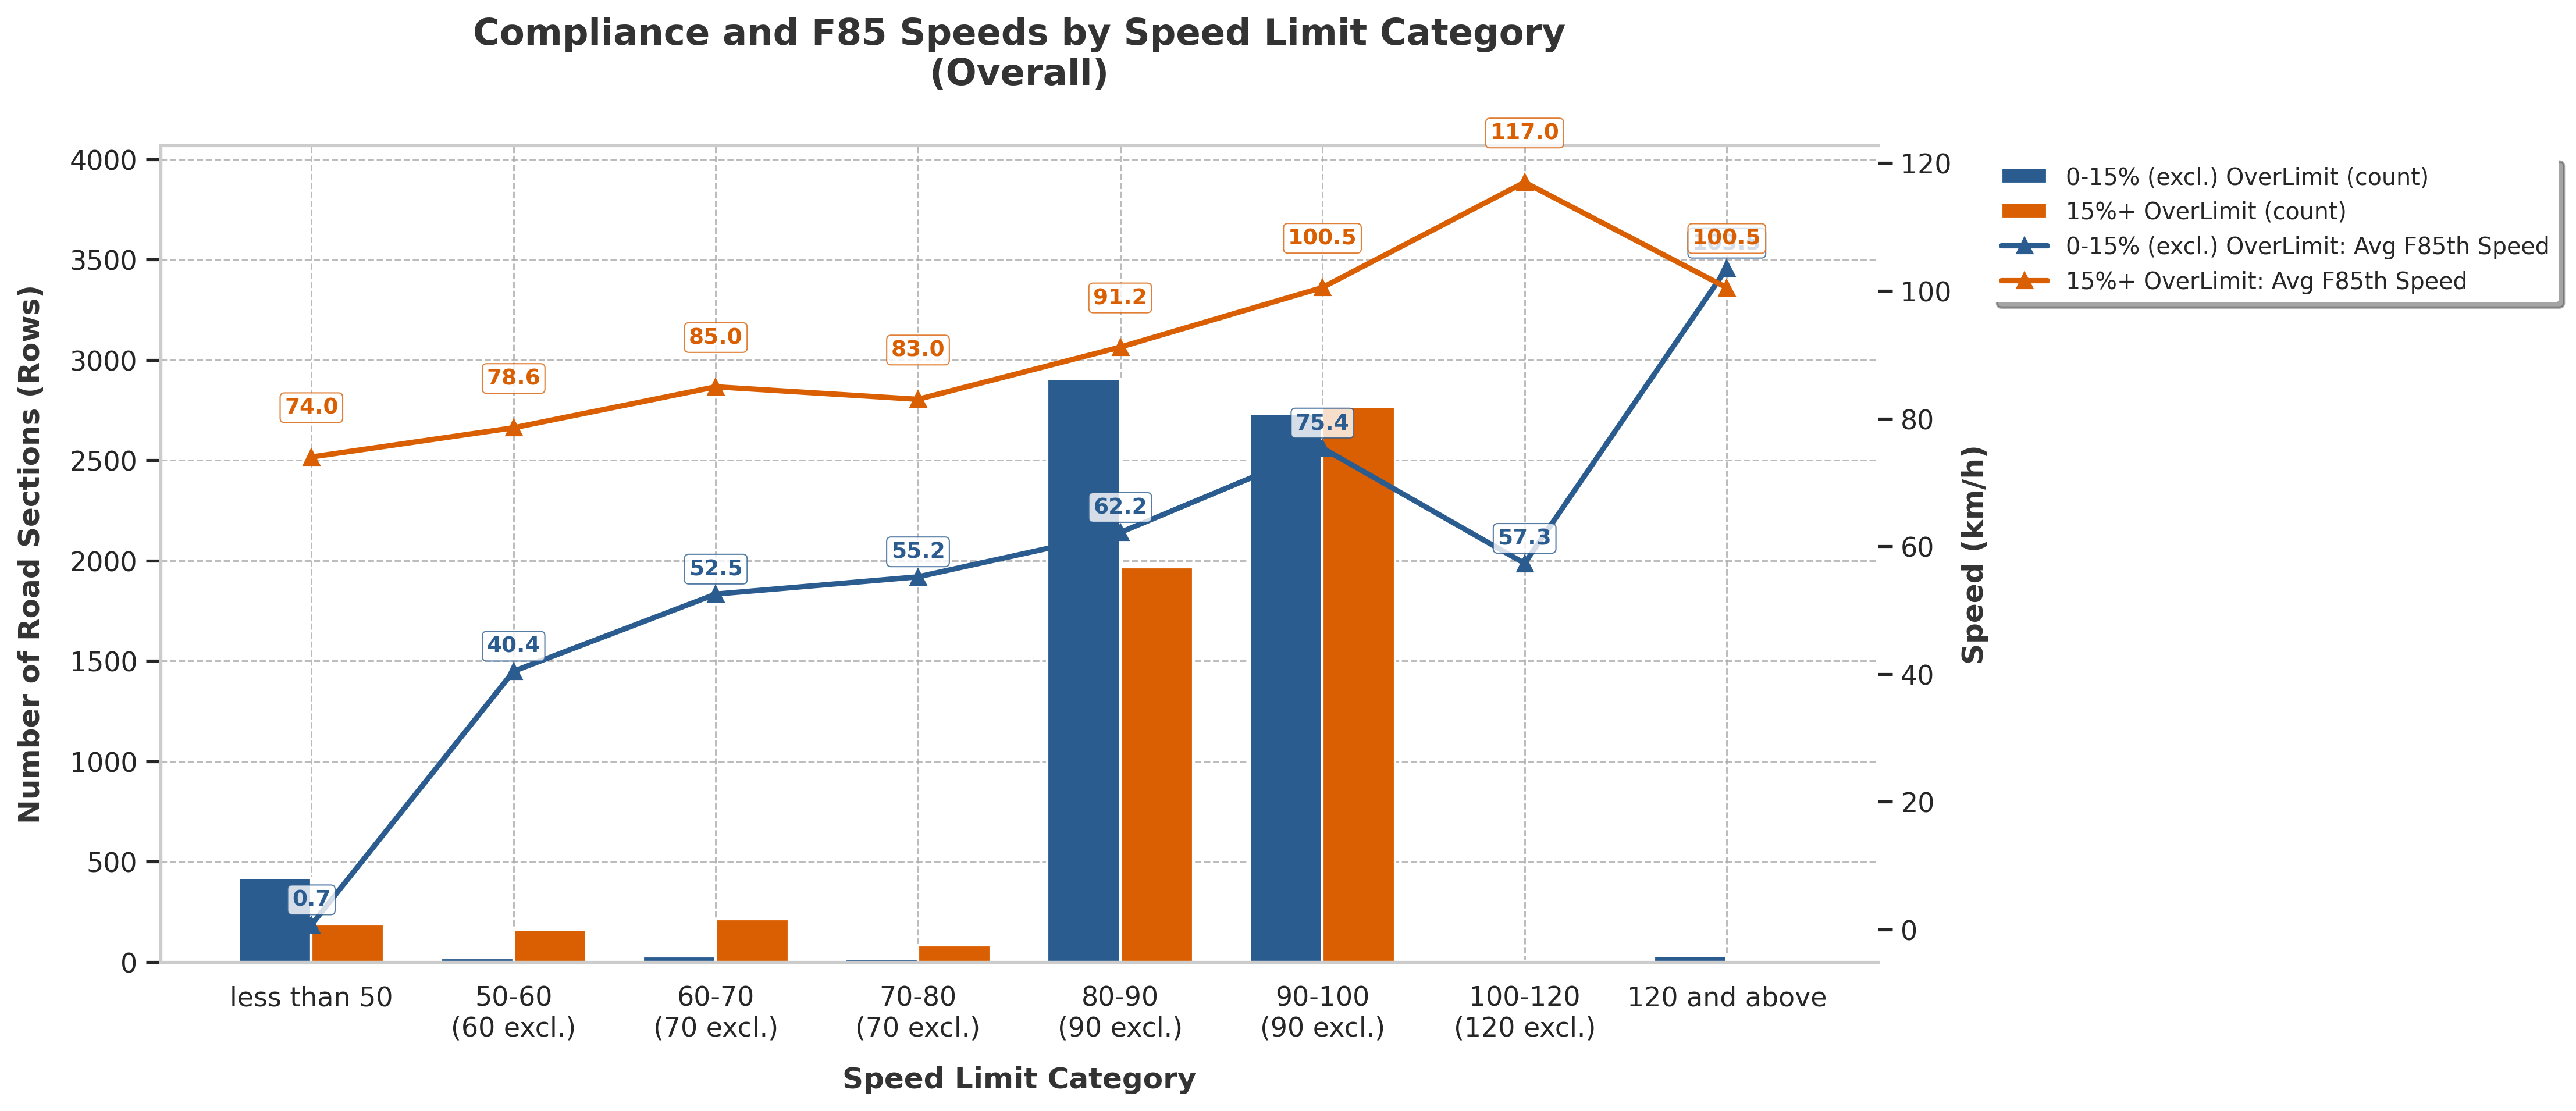

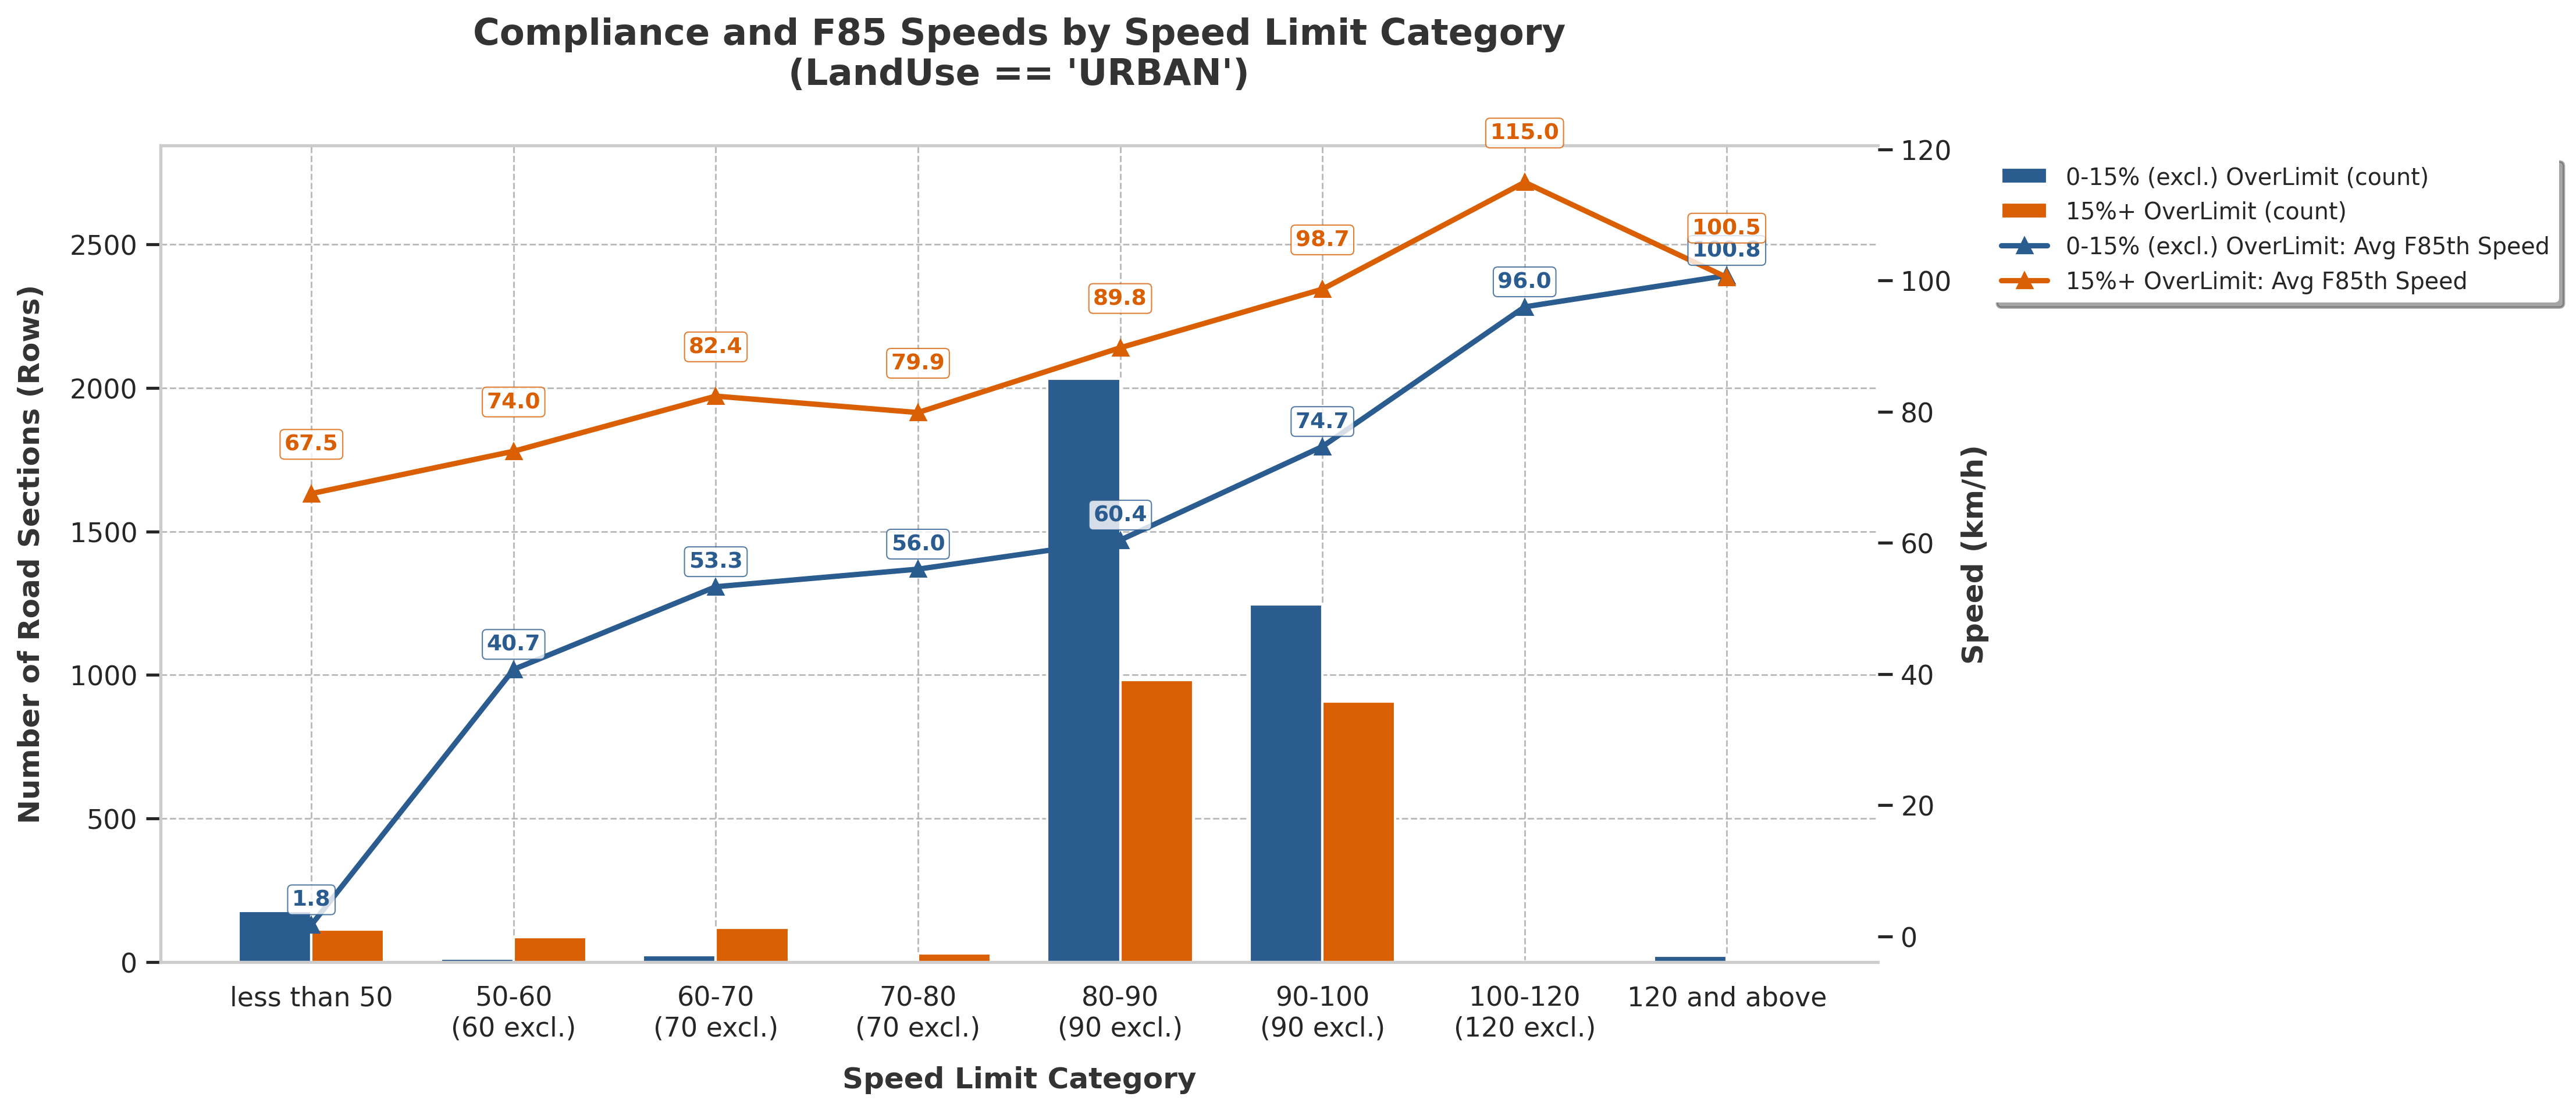

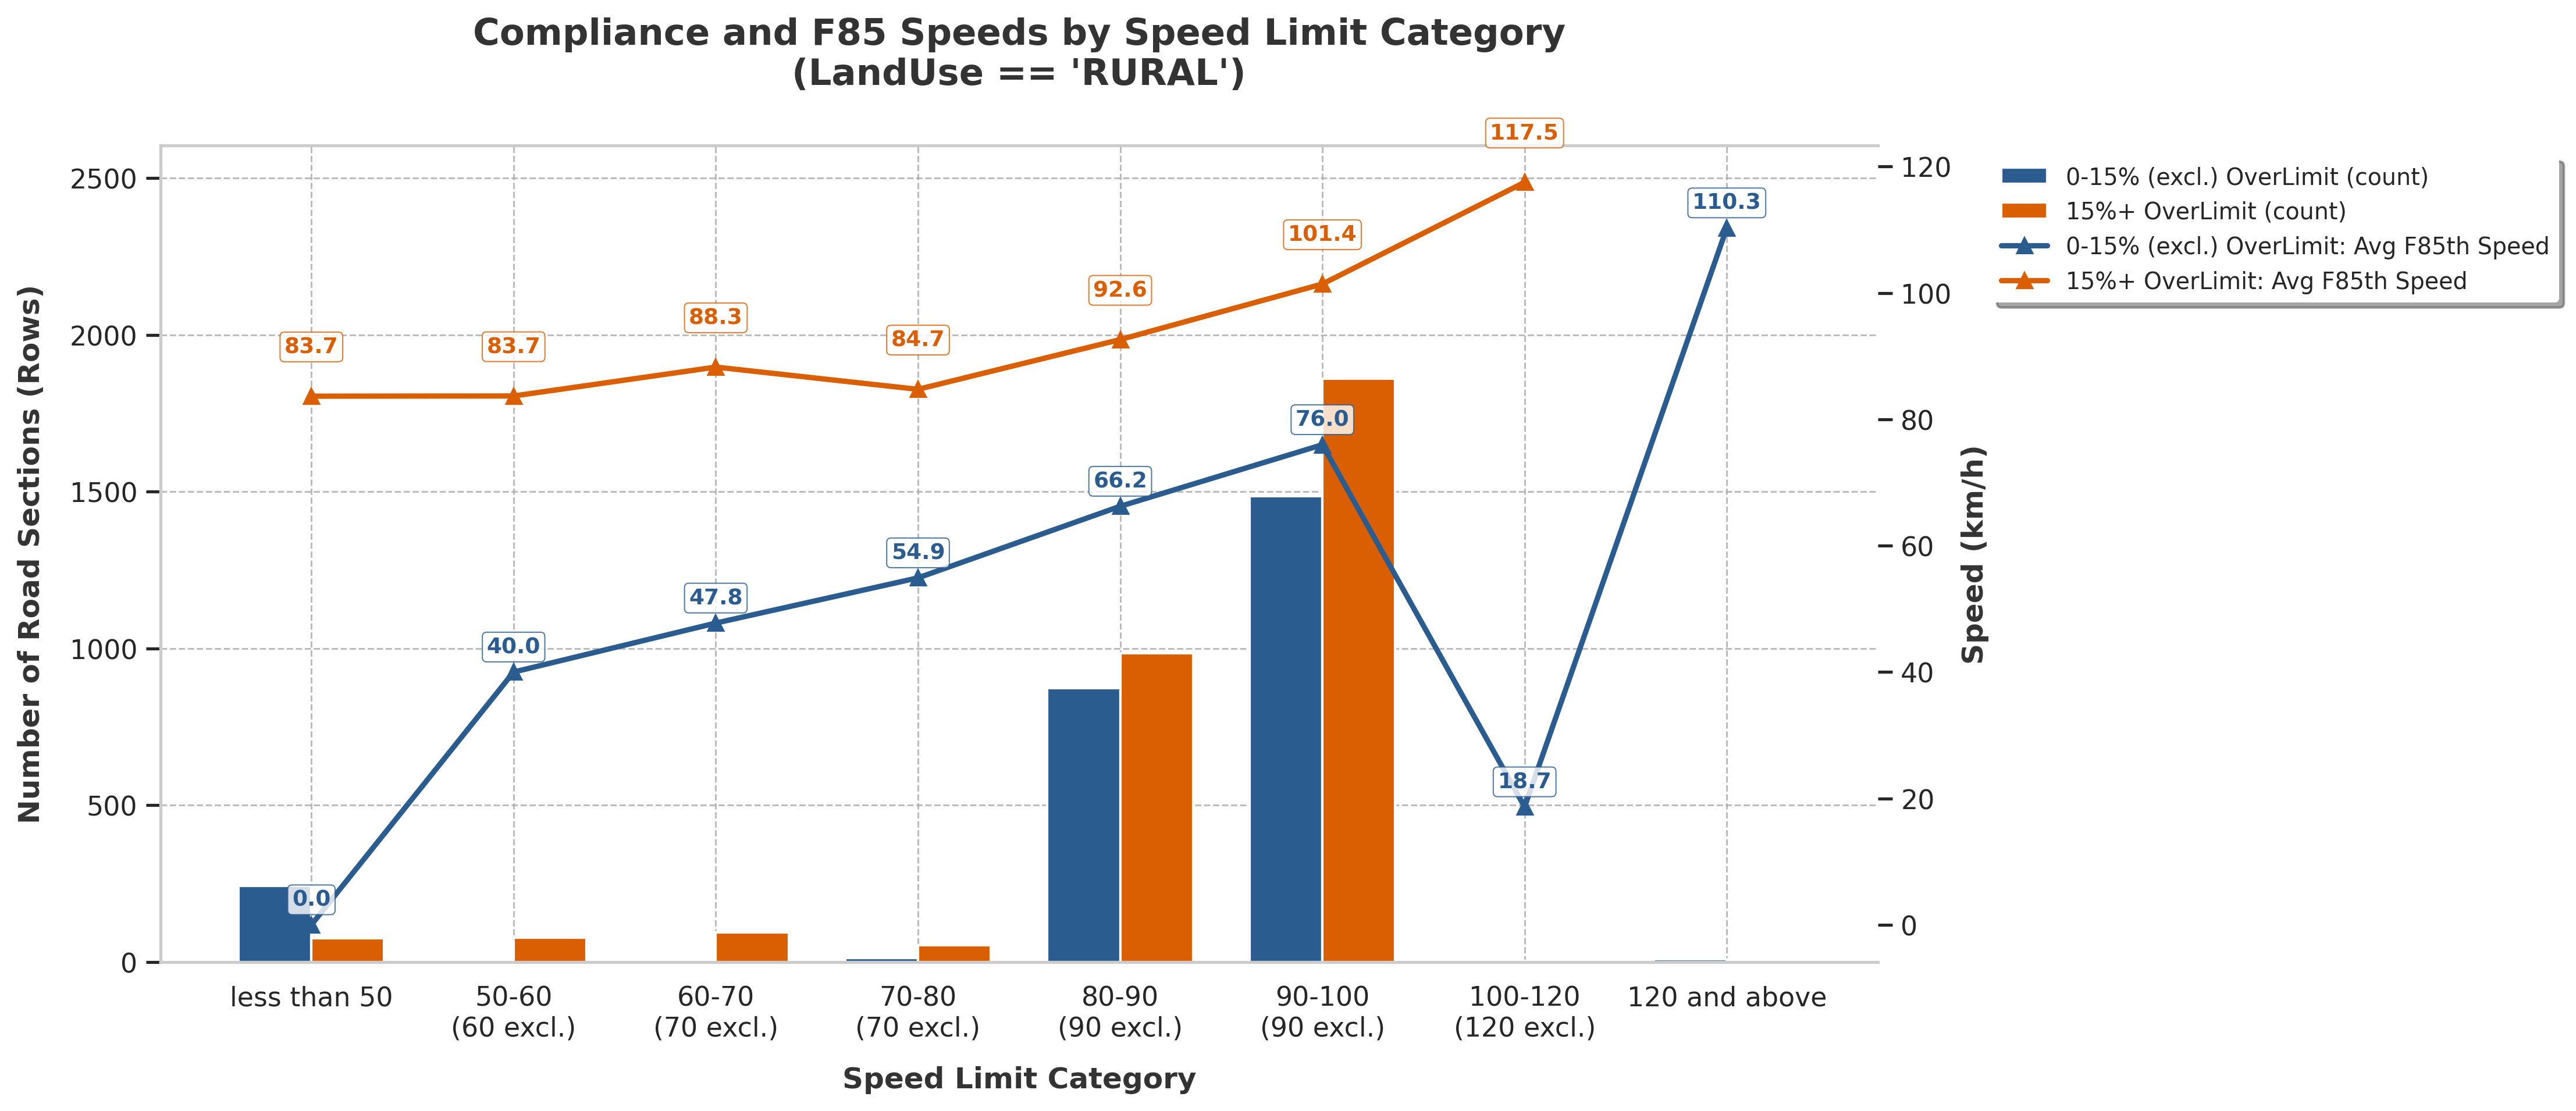

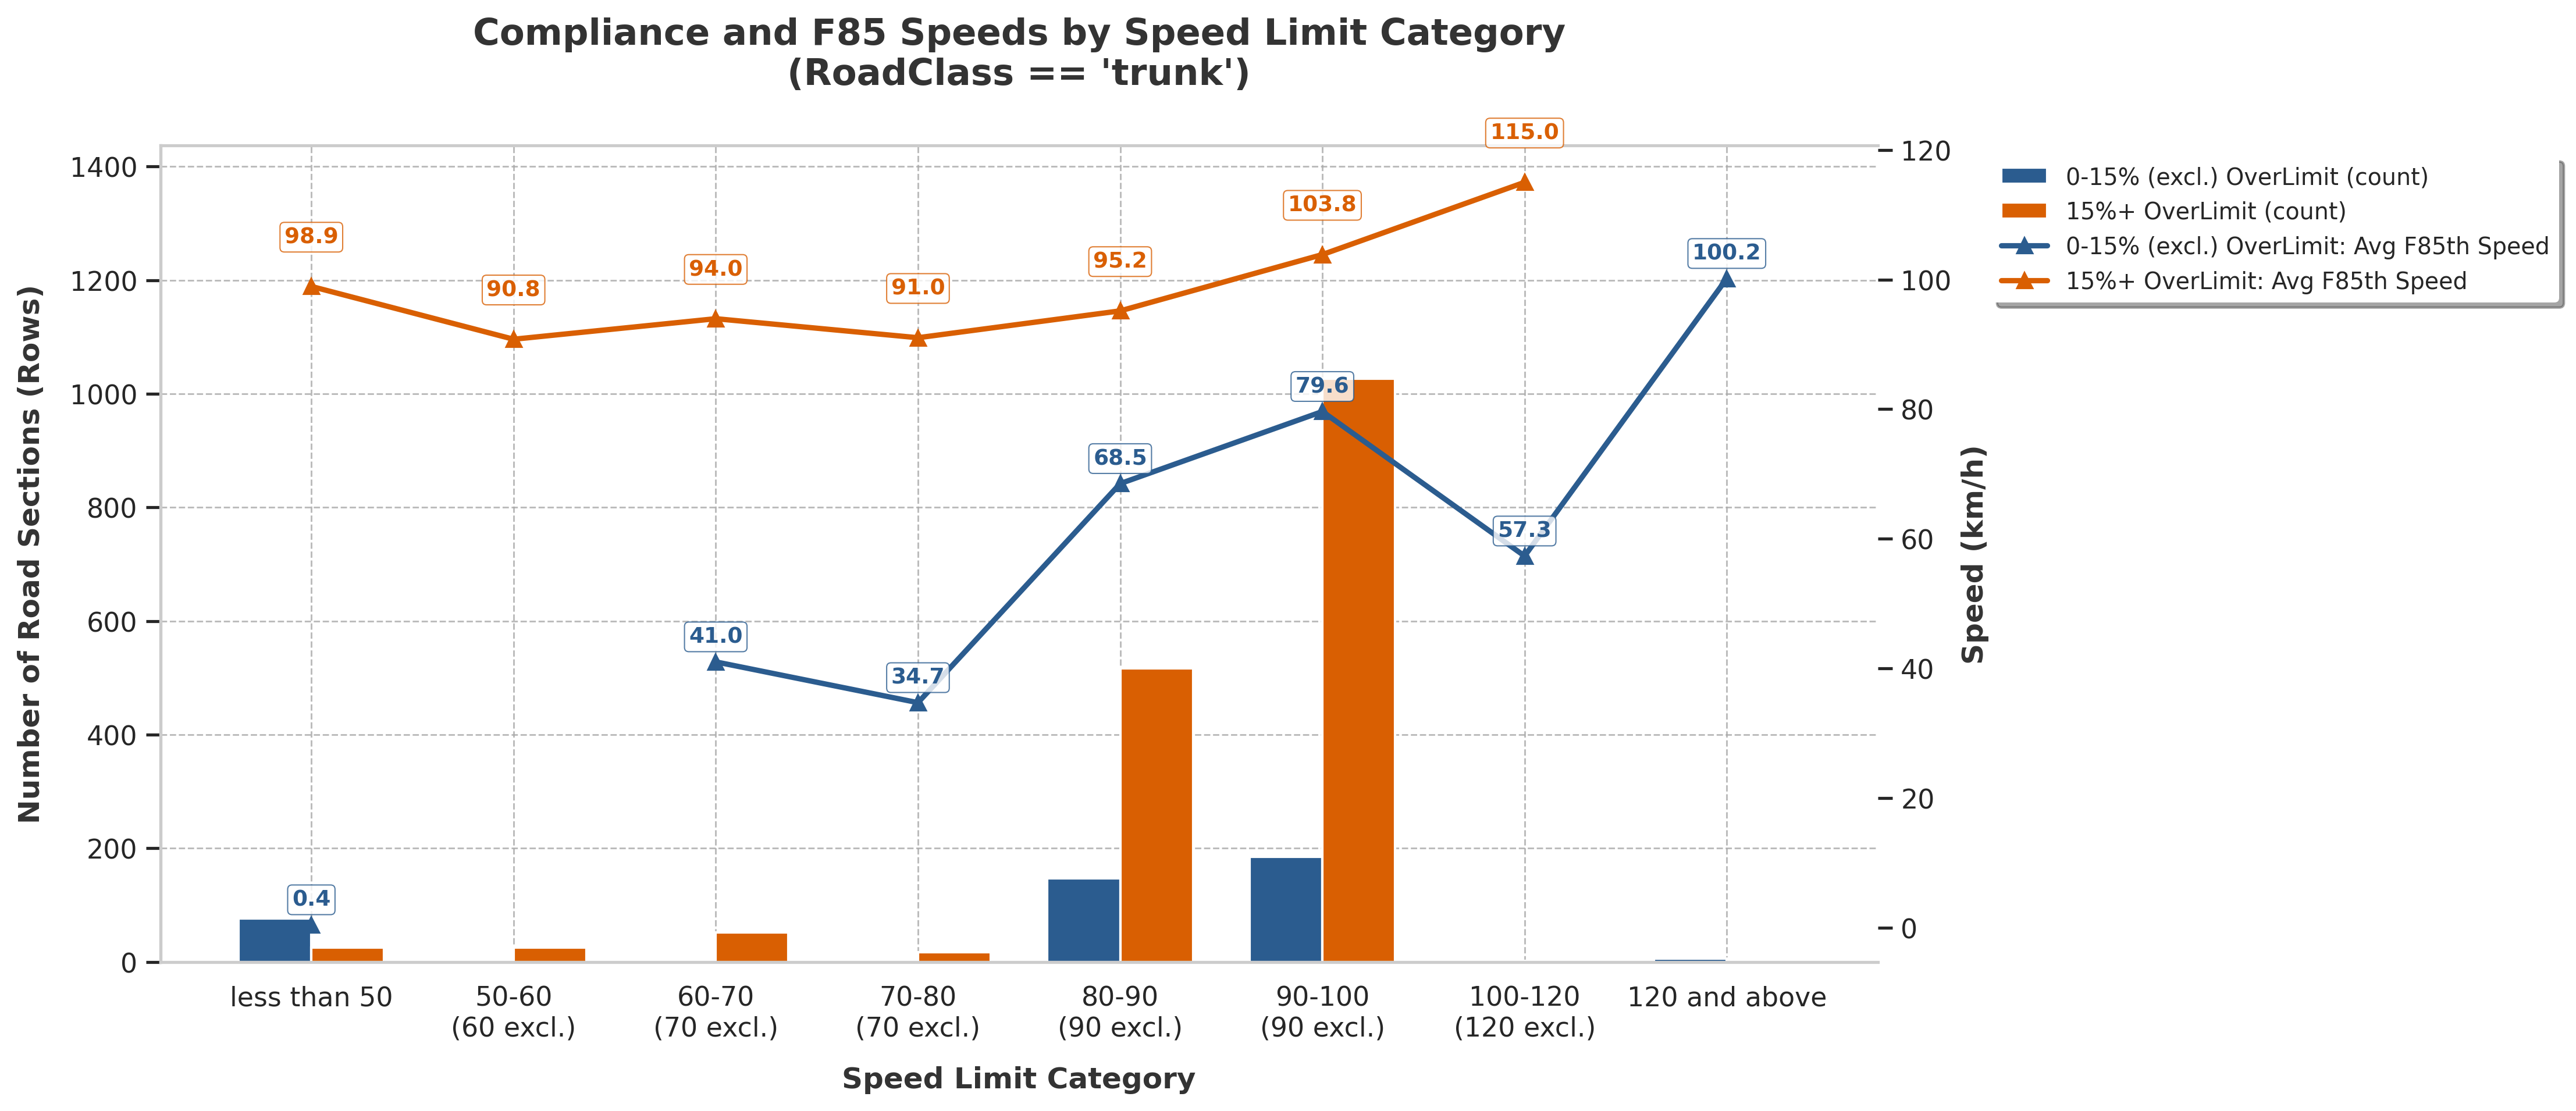

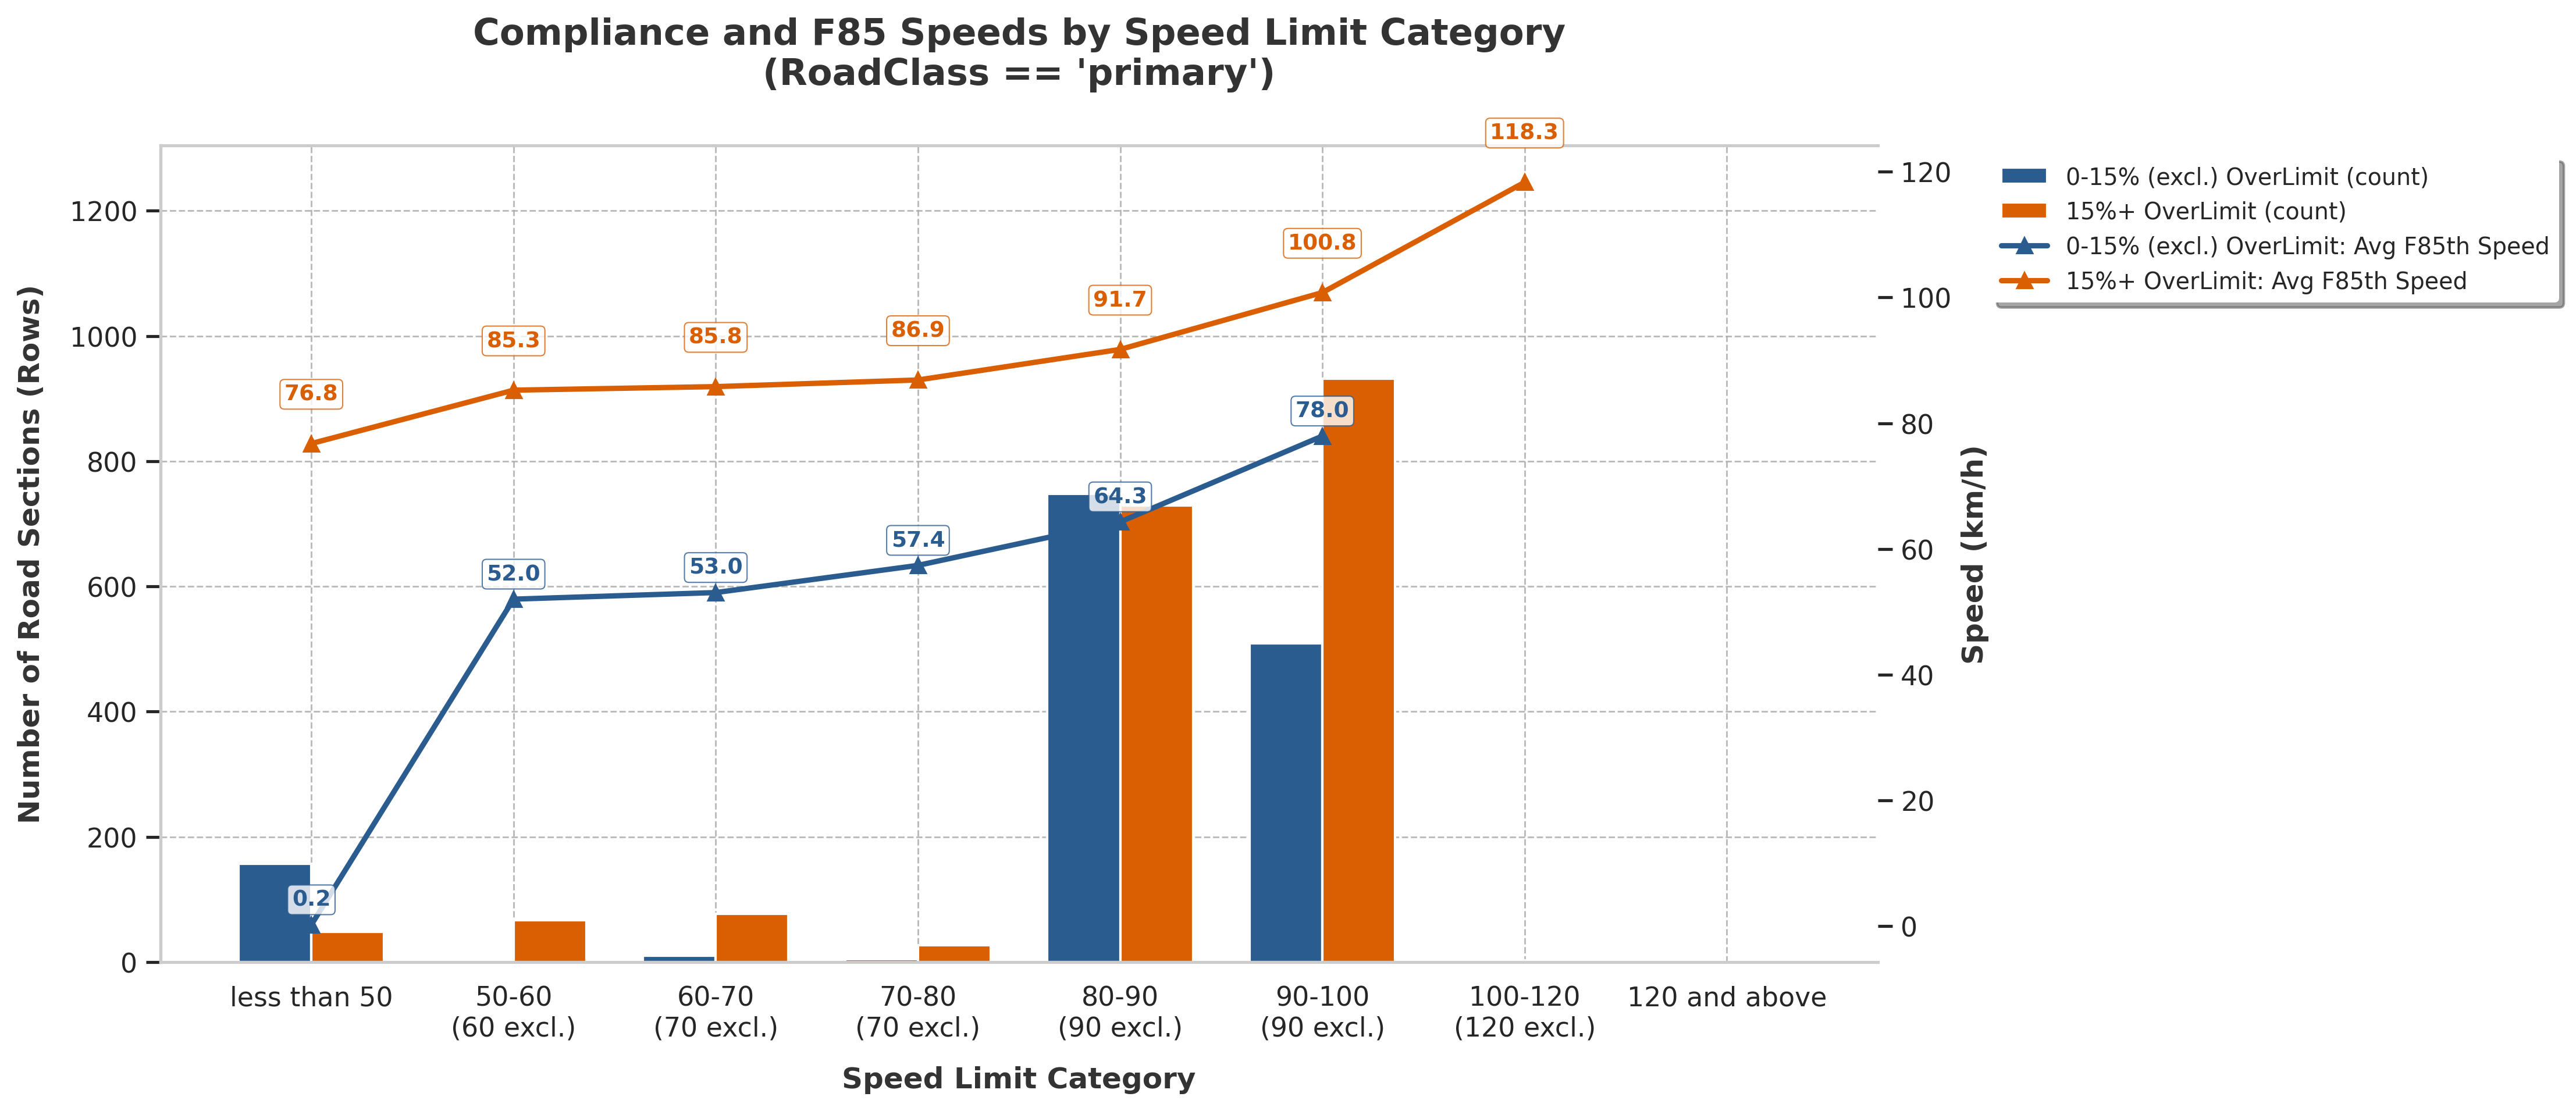

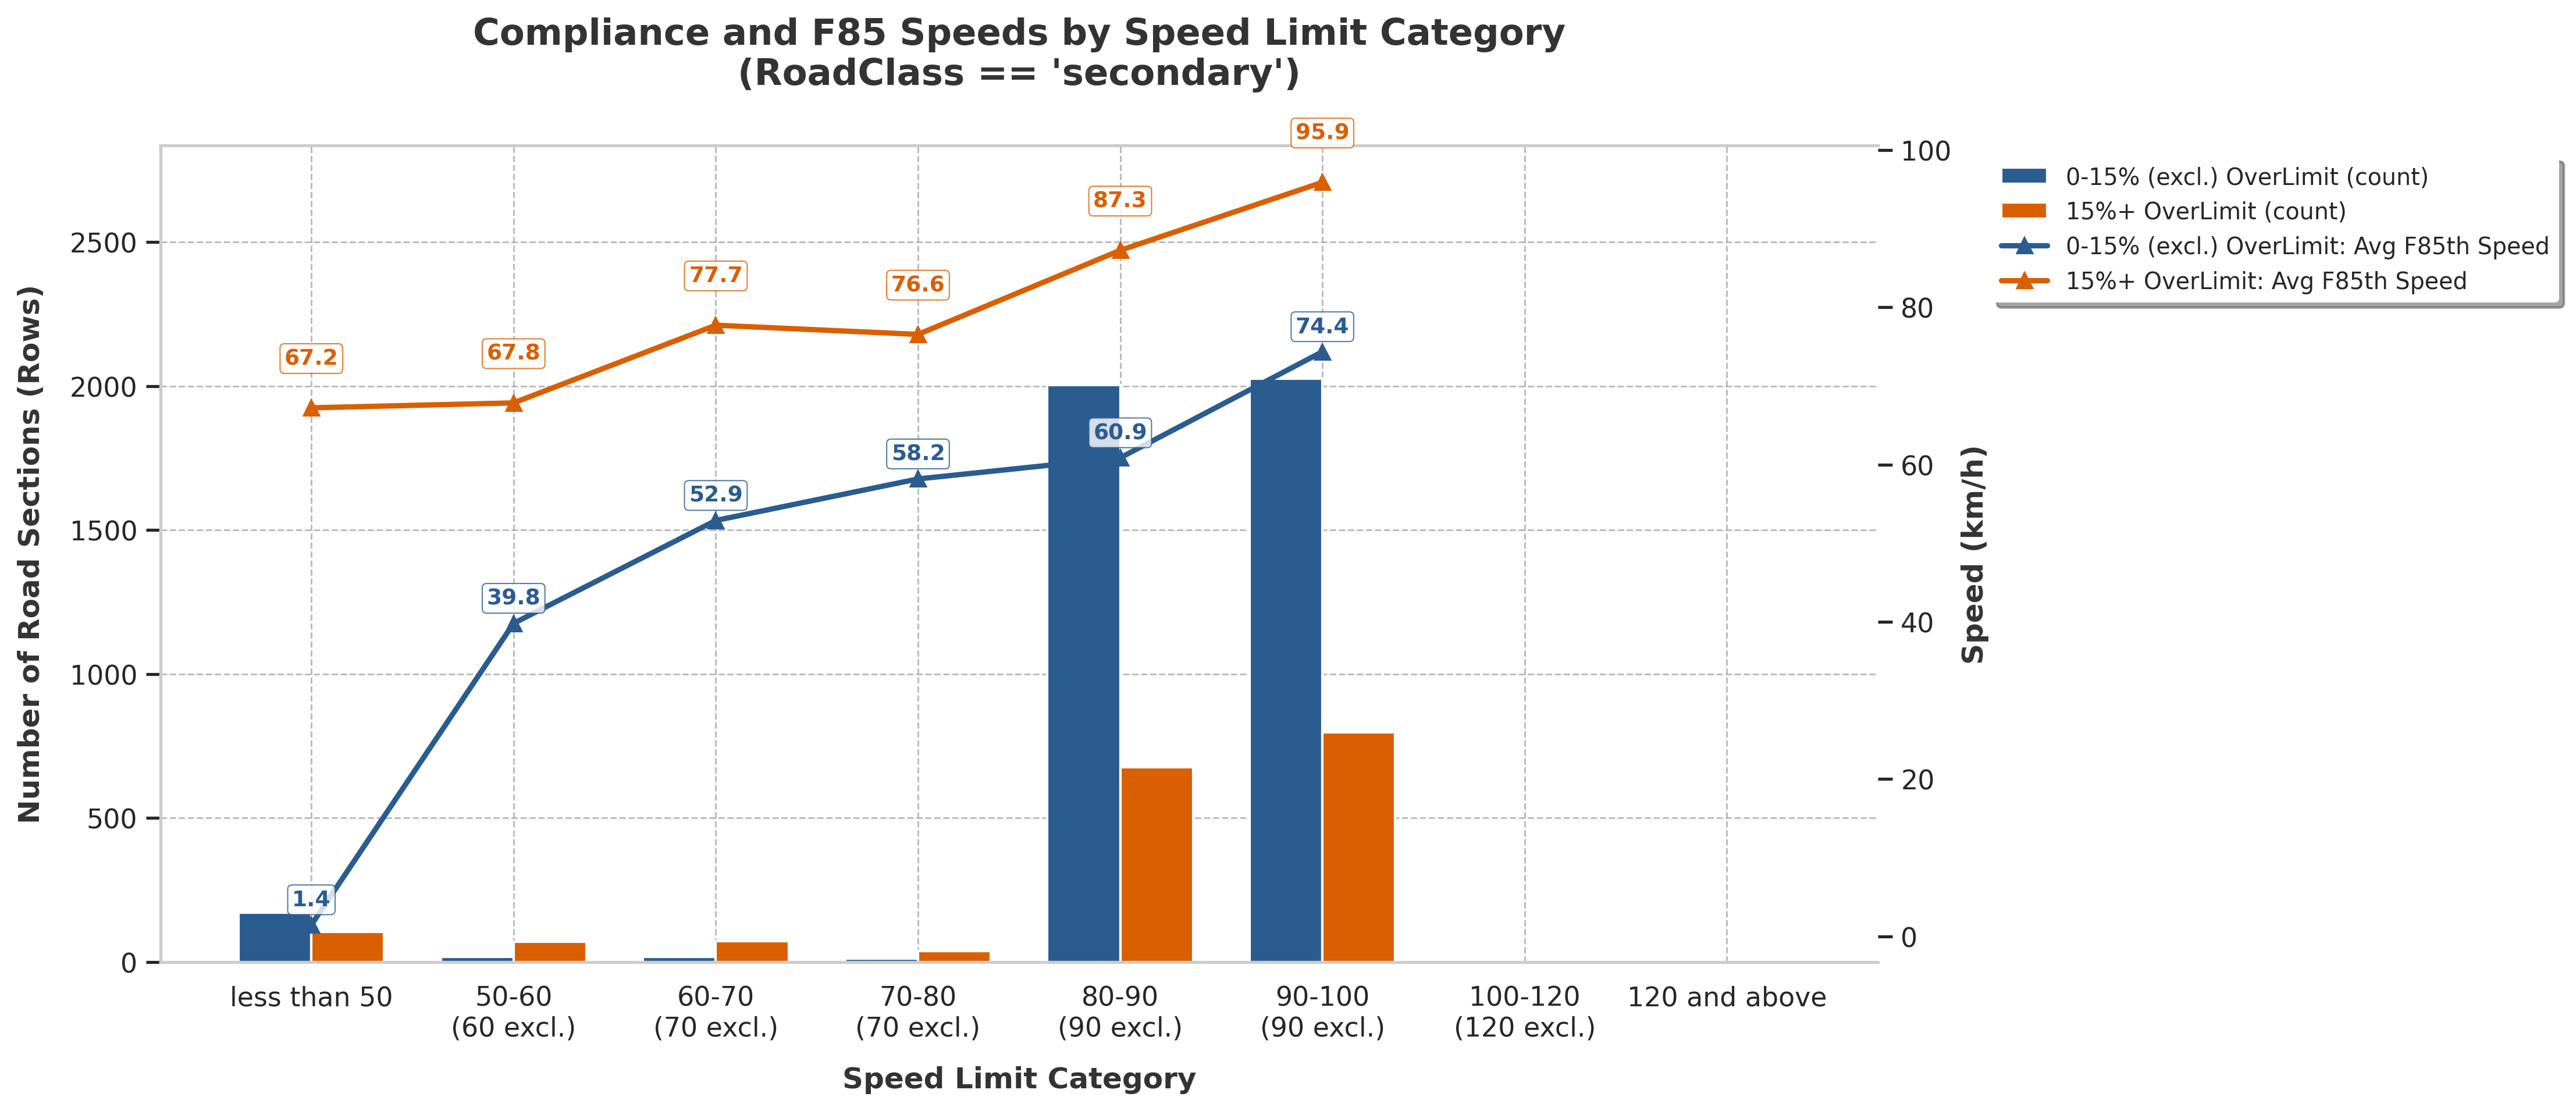

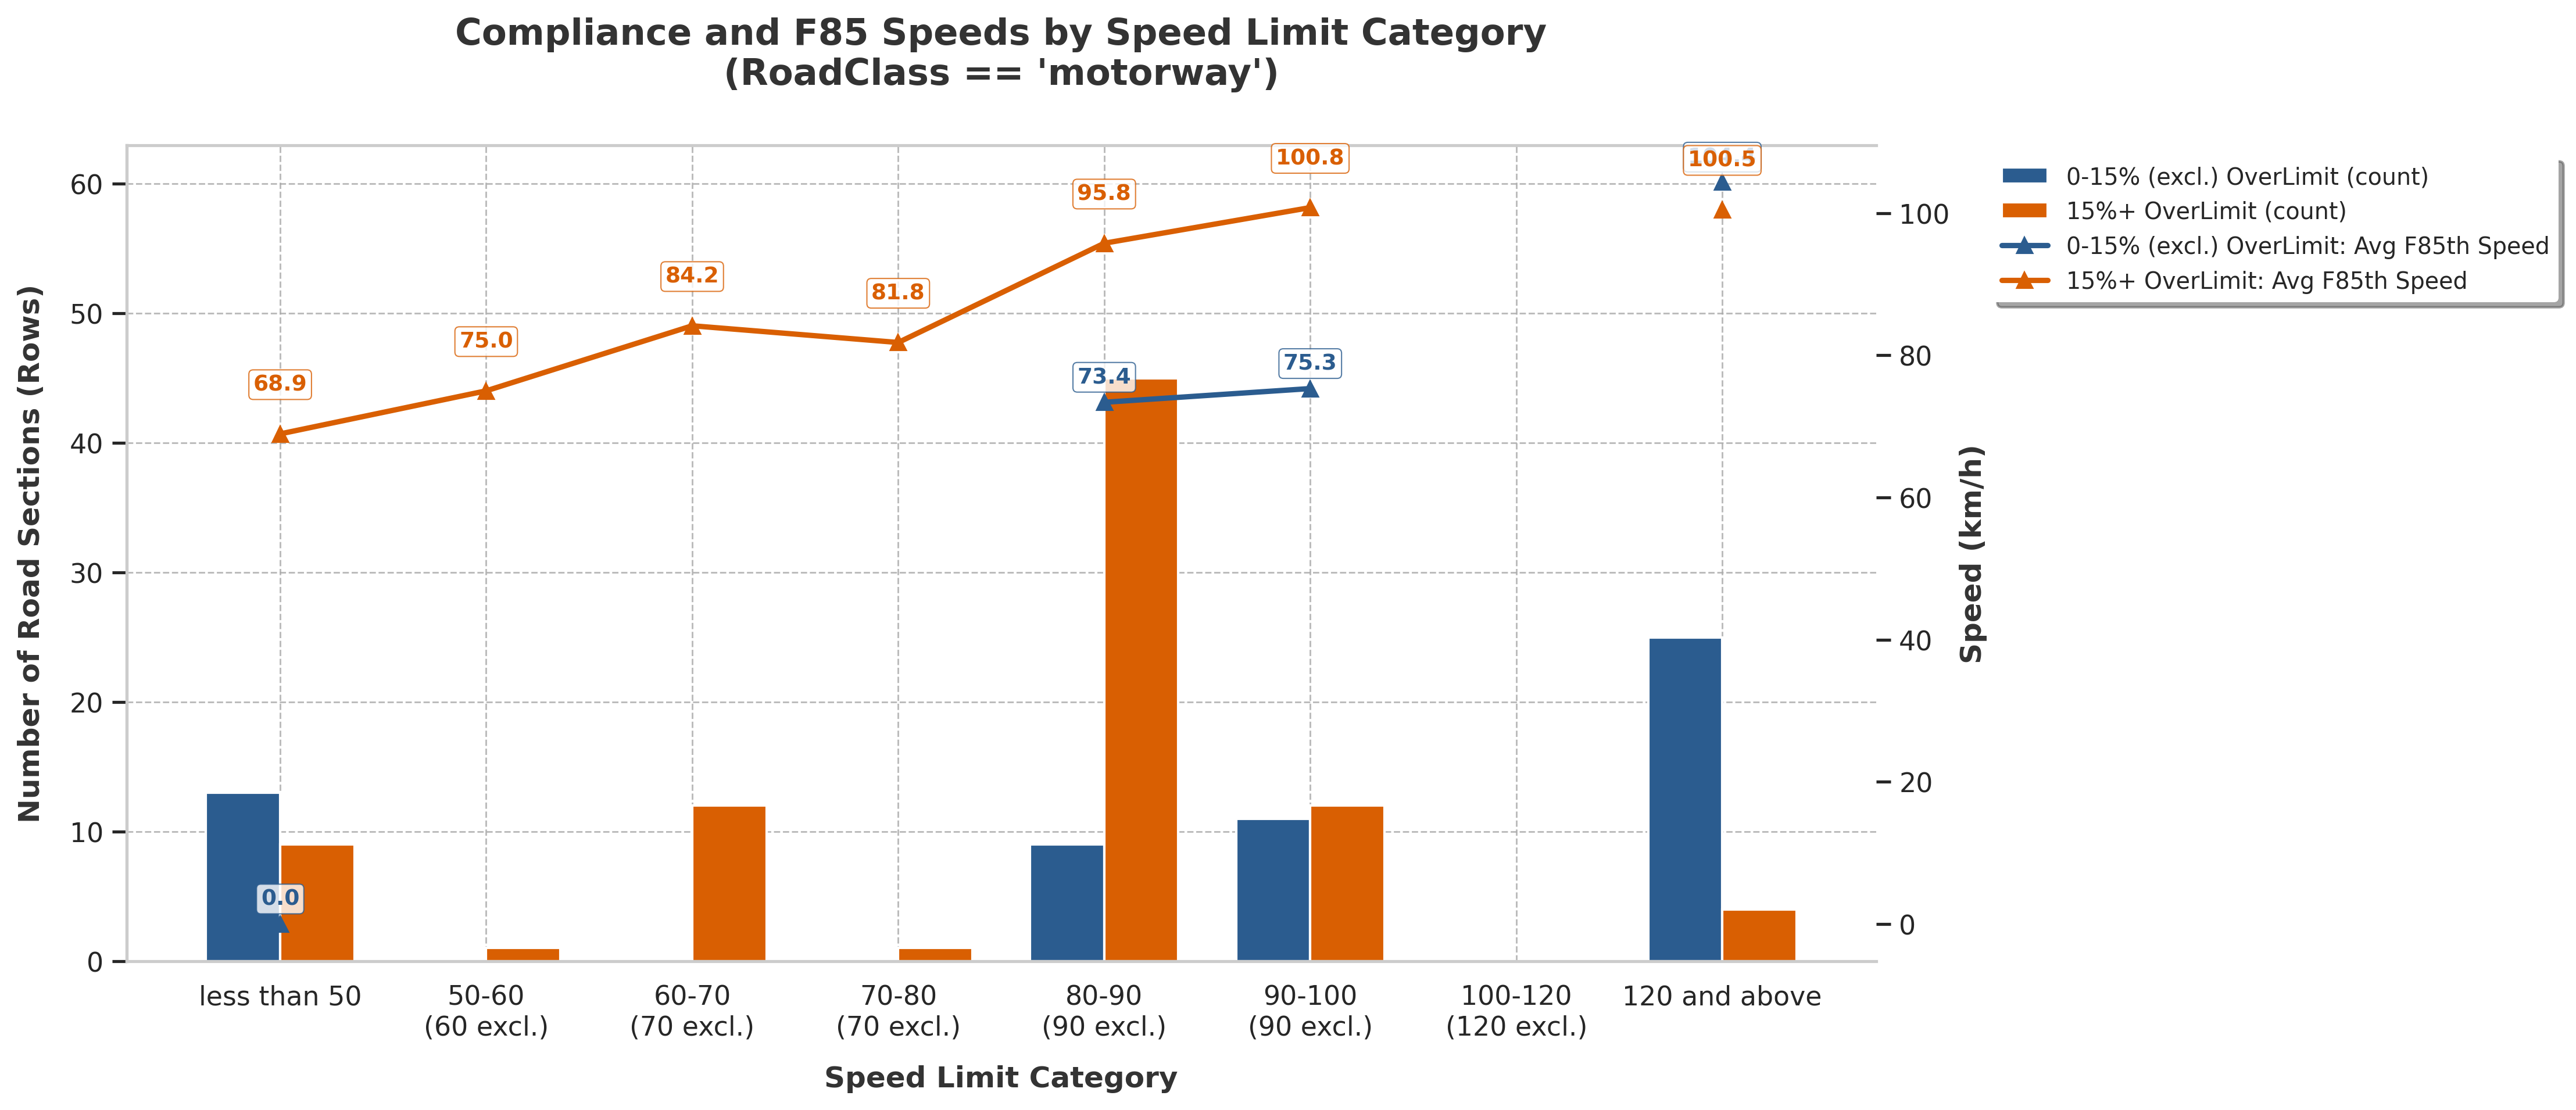

In [21]:
thai_filter['SpeedCategory'] = thai_filter[speed_col].apply(categorize_speed)

def create_compliance_plot(df, title_text):
    categories_order = [
        "less than 50", "50-60 (60 not incl.)", "60-70 (70 not incl.)", "70-80 (80 not incl.)",
        "80-90 (90 not incl.)", "90-100 (100 not incl.)", "100-120 (120 not incl.)", "120 and above"
    ]
    cat_labels_clean = [
        "less than 50", "50-60\n(60 excl.)", "60-70\n(70 excl.)", "70-80\n(70 excl.)",
        "80-90\n(90 excl.)", "90-100\n(90 excl.)", "100-120\n(120 excl.)", "120 and above"
    ]

    count_under_15, count_15_plus = [], []
    f85_under_15, f85_15_plus = [], []

    for cat in categories_order:
        group = df[df['SpeedCategory'] == cat]
        if len(group) == 0:
            count_under_15.append(0); count_15_plus.append(0)
            f85_under_15.append(np.nan); f85_15_plus.append(np.nan)
        else:
            g_under_15 = group[group['PercentOverLimit'] < 15]
            g_15_plus = group[group['PercentOverLimit'] >= 15]
            count_under_15.append(len(g_under_15))
            count_15_plus.append(len(g_15_plus))
            f85_under_15.append(g_under_15['F85thPercentileSpeed'].mean() if len(g_under_15) > 0 else np.nan)
            f85_15_plus.append(g_15_plus['F85thPercentileSpeed'].mean() if len(g_15_plus) > 0 else np.nan)

    # plotting
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.size'] = 11
    x = np.arange(len(categories_order))
    width = 0.36
    fig, ax = plt.subplots(figsize=(15, 6.5), dpi=300)
    c_under_15, c_15_plus = '#2b5c8f', '#d95f02'

    # grid only left bar
    ax.grid(True, linestyle='--', linewidth=0.7, color='#aaaaaa', alpha=0.8)
    ax.set_axisbelow(True)

    ax.bar(x - width/2, count_under_15, width, label='0-15% (excl.) OverLimit (count)', color=c_under_15)
    ax.bar(x + width/2, count_15_plus, width, label='15%+ OverLimit (count)', color=c_15_plus)

    ax.set_title(title_text, fontsize=15, pad=25, fontweight='bold', color='#333333')
    ax.set_xlabel('Speed Limit Category', fontsize=12, labelpad=10, fontweight='bold', color='#333333')
    ax.set_ylabel('Number of Road Sections (Rows)', fontsize=12, labelpad=10, fontweight='bold', color='#333333')
    ax.set_xticks(x)
    ax.set_xticklabels(cat_labels_clean)
    ax.set_ylim(0, max(max(count_under_15 + [1]), max(count_15_plus + [1])) * 1.4)

    # right bar
    ax2 = ax.twinx()
    ax2.grid(False) # No grod
    ax2.plot(x, f85_under_15, marker='^', linestyle='-', linewidth=2.2, color=c_under_15, label='0-15% (excl.) OverLimit: Avg F85th Speed')
    ax2.plot(x, f85_15_plus, marker='^', linestyle='-', linewidth=2.2, color=c_15_plus, label='15%+ OverLimit: Avg F85th Speed')
    ax2.set_ylabel('Speed (km/h)', fontsize=12, fontweight='bold', color='#333333')

    def add_line_labels(x_pos, y_values, color, offset_y):
        for idx, val in enumerate(y_values):
            if not np.isnan(val):
                ax2.annotate(f'{val:.1f}', xy=(x_pos[idx], val), xytext=(0, offset_y), textcoords="offset points",
                             ha='center', va='bottom', fontsize=9, fontweight='bold', color=color,
                             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, lw=0.5, alpha=0.8))

    add_line_labels(x, f85_under_15, c_under_15, offset_y=6)
    add_line_labels(x, f85_15_plus, c_15_plus, offset_y=16)

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, bbox_to_anchor=(1.06, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='none', shadow=True, fontsize=9.5)

    sns.despine(ax=ax, left=False, bottom=True, right=True)
    ax2.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

create_compliance_plot(thai_filter, 'Compliance and F85 Speeds by Speed Limit Category\n(Overall)')

segment_map = {
    "URBAN": "LandUse == 'URBAN'", "RURAL": "LandUse == 'RURAL'",
    "trunk": "RoadClass == 'trunk'", "primary": "RoadClass == 'primary'",
    "secondary": "RoadClass == 'secondary'", "motorway": "RoadClass == 'motorway'"
}

for name, query in segment_map.items():
    subset = thai_filter.query(query)
    create_compliance_plot(subset, f'Compliance and F85 Speeds by Speed Limit Category\n({query})')

## 3. Causal Model 1 (Backdoor Liner Regression)

In [22]:
# Accident data is source from https://datagov.mot.go.th/th/dataset/roadaccident (dataset in 2024)
# We translated the columns and filter as:
  #Fatal accidents only (Deaths > 0)
  # Vehicle Types: Passenger vehicles (4-Wheel Pickup Trucks and Private/Public Passenger Cars)
  # Presumed Cause: Speeding-related incidents
# Mapped defined accident counts to thai_senario1.geojson, applying a 5-meter buffer to all filtered accidents.

In [ ]:
#DAG Model code (https://www.dagitty.net/dags.html#)
"""
dag {
bb="-1.8,-2,0.5,0.5"
Enforcement [pos="-1.568,-0.254"]
F85thPercentileSpeed [pos="-0.336,-1.285"]
LandUse [pos="-1.595,-0.890"]
PercentOverLimit [pos="-0.354,-0.588"]
RoadClass [pos="-1.587,-1.583"]
SpeedLimit [exposure,pos="-0.331,-1.813"]
accident_rate [outcome,pos="0.306,-0.646"]
speed_violation_rate [pos="-0.377,0.037"]
Enforcement -> F85thPercentileSpeed
Enforcement -> PercentOverLimit
Enforcement -> speed_violation_rate
F85thPercentileSpeed -> accident_rate
LandUse -> F85thPercentileSpeed
LandUse -> PercentOverLimit
LandUse -> speed_violation_rate
PercentOverLimit -> accident_rate
RoadClass -> F85thPercentileSpeed
RoadClass -> PercentOverLimit
RoadClass -> speed_violation_rate
SpeedLimit -> F85thPercentileSpeed
speed_violation_rate -> accident_rate
}
"""

In [23]:
! pip install dowhy

In [24]:
from dowhy import CausalModel
import dowhy.datasets

In [36]:
data = gpd.read_file('/content/thai_senario2.geojson')

In [37]:
data['Group'] = data['RoadClass'] + "_" + data['LandUse']

grouped_data = {group: data[data['Group'] == group] for group in data['Group'].unique()}

for group, subset in grouped_data.items():
    print(f"Group: {group}, Count: {len(subset)}")

Group: primary_RURAL, Count: 1489
Group: primary_URBAN, Count: 1823
Group: secondary_URBAN, Count: 2861
Group: motorway_URBAN, Count: 115
Group: motorway_RURAL, Count: 27
Group: secondary_RURAL, Count: 3144
Group: trunk_URBAN, Count: 962
Group: trunk_RURAL, Count: 1123


In [38]:
# target speed thresholds
thresholds = {
    'secondary_URBAN': 60, 'secondary_RURAL': 60,
    'motorway_URBAN': 120, 'motorway_RURAL': 120,
    'trunk_URBAN': 60,'trunk_RURAL': 100,
    'primary_URBAN': 60,'primary_RURAL': 100
    }

for group in data['Group'].unique():
    if group not in thresholds:
        continue

    subset = data[data['Group'] == group]
    limit = thresholds[group]

    # Number of segments below the speed limit thresholds
    within_limit = subset[subset['F85thPercentileSpeed'] < limit]
    count_within = len(within_limit)

    # At or below the speed limit thresholds and involved in an accident in 2024
    accidents_in_subset = within_limit[within_limit['accidents_2024'] > 0]
    count_accidents = len(accidents_in_subset)

    print(f"Group: {group}, Count: {len(subset)}, "
          f"within speedlimit segment is {count_within} out of {len(subset)}, "
          f"out of {count_within} segments, {count_accidents} segments has historical accidents in 2024")

Group: primary_RURAL, Count: 1489, within speedlimit segment is 980 out of 1489, out of 980 segments, 37 segments has historical accidents in 2024
Group: primary_URBAN, Count: 1823, within speedlimit segment is 301 out of 1823, out of 301 segments, 0 segments has historical accidents in 2024
Group: secondary_URBAN, Count: 2861, within speedlimit segment is 923 out of 2861, out of 923 segments, 8 segments has historical accidents in 2024
Group: motorway_URBAN, Count: 115, within speedlimit segment is 115 out of 115, out of 115 segments, 9 segments has historical accidents in 2024
Group: motorway_RURAL, Count: 27, within speedlimit segment is 27 out of 27, out of 27 segments, 0 segments has historical accidents in 2024
Group: secondary_RURAL, Count: 3144, within speedlimit segment is 460 out of 3144, out of 460 segments, 4 segments has historical accidents in 2024
Group: trunk_URBAN, Count: 962, within speedlimit segment is 55 out of 962, out of 55 segments, 1 segments has historical acc

In [51]:
#Blocking back-door paths caused by RoadClass and LandUse to isolate causal effects within this specific road environment.

#df = data[(data['RoadClass'] == 'primary') & (data['LandUse'] == 'URBAN')].copy()  #1823
#df = data[(data['RoadClass'] == 'primary') & (data['LandUse'] == 'RURAL')].copy()  #1489
df = data[(data['RoadClass'] == 'secondary') & (data['LandUse'] == 'URBAN')].copy()  #2861
#df = data[(data['RoadClass'] == 'secondary') & (data['LandUse'] == 'RURAL')].copy()  #3144
#df = data[(data['RoadClass'] == 'trunk') & (data['LandUse'] == 'RURAL')].copy() #1123
#df = data[(data['RoadClass'] == 'trunk') & (data['LandUse'] == 'URBAN')].copy() #962
#df = data[(data['RoadClass'] == 'motorway') & (data['LandUse'] == 'URBAN')].copy() #115
#df = data[(data['RoadClass'] == 'motorway') & (data['LandUse'] == 'RURAL')].copy() #27

print(f"number of dataset: {len(df)}")
print(df.head())

df_secondary_urban = data[(data['RoadClass'] == 'secondary') & (data['LandUse'] == 'URBAN')].copy()
df_secondary_urban.to_file('secondary_urban.geojson', driver='GeoJSON')

len(df_secondary_urban)

number of dataset: 2861
   OBJECTID          english_ro  OvertureID  SampleSize_avg  RoadLength  \
4        18  Sukhaphiban 5 Road          18        744341.0         0.2   
5        19  Sukhaphiban 5 Road          19        535558.0         4.2   
6        26        Si Chan Road          26        418943.5         1.0   
7        27        Si Chan Road          27        525354.0         2.7   
8        28        Si Chan Road          28        587241.0         2.7   

   WeightedSample  Percent_  Percentile  SpeedLimit  RoadClass  ...  \
4        148868.2  0.000003    0.004772        80.0  secondary  ...   
5       2249343.6  0.000043    0.078758        80.0  secondary  ...   
6        418943.5  0.000008    0.018083        80.0  secondary  ...   
7       1418455.8  0.000027    0.056239        80.0  secondary  ...   
8       1585550.7  0.000030    0.060910        80.0  secondary  ...   

                                 StreetImageLink  LandUse  \
4   100.6520076,13.8817104,100.655448

2861

In [52]:
dag_graph = """
digraph {
    F85thPercentileSpeed -> log_accident_rate;
    PercentOverLimit -> log_accident_rate;
    SpeedLimit -> F85thPercentileSpeed;
    SpeedLimit -> PercentOverLimit;
}
"""

In [53]:
from sklearn.preprocessing import StandardScaler

df = gpd.read_file('/content/secondary_urban.geojson')

cols_to_use = ['F85thPercentileSpeed', 'PercentOverLimit', 'SpeedLimit', 'accidents_2024', 'WeightedSample']
df = df[cols_to_use].copy()

# accident_rate
df['accident_rate'] = df['accidents_2024'] / df['WeightedSample']
df['accident_rate'] = df['accident_rate'].fillna(0).replace([np.inf, -np.inf], 0)

# log scale
df['log_accident_rate'] = np.log(df['accident_rate'] + 1e-12)

# StandardScaler
scaler = StandardScaler()
numeric_cols = ['F85thPercentileSpeed', 'PercentOverLimit', 'SpeedLimit']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df_final = df.drop(columns=['accidents_2024', 'WeightedSample', 'accident_rate'], errors='ignore')
df_final = df_final.astype(float)

print(f"len of this group: {len(df_final)} ")
print(df_final.head())

len of this group: 2861 
   F85thPercentileSpeed  PercentOverLimit  SpeedLimit  log_accident_rate
0              0.455366         -0.073788    0.068632         -27.631021
1             -1.368257         -0.550989    0.068632         -27.631021
2             -1.605091         -0.550989    0.068632         -27.631021
3             -0.444604         -0.550989    0.068632         -27.631021
4             -0.349870         -0.550989    0.068632         -27.631021


In [54]:
df_final['log_accident_rate'].describe()

,log_accident_rate
count,2861.000000
mean,-27.466242
std,1.557824
min,-27.631021
25%,-27.631021
50%,-27.631021
75%,-27.631021
max,-9.990197


In [55]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning, module='statsmodels')

# Model initialization
model = CausalModel(
    data=df_final,
    treatment='F85thPercentileSpeed',
    outcome='log_accident_rate',
    graph=dag_graph
)

# Identification
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

# Estimation
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)
print(f"Mean value: {estimate.value}")

# Refutation
refutation_subset = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8 # Will the same results be obtained even if 20% of the data is removed?
)
print(refutation_subset)

ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


Mean value: 0.06769778623103662
Refute: Use a subset of data
Estimated effect:0.06769778623103662
New effect:0.06750425620906729
p value:0.98



In [56]:
#Result Summary per Road Category
data = [
    {"Category": "Primary × URBAN", "Estimated": 0.11288244945818704, "New": 0.11162399271277654, "p_value": 0.92},
    {"Category": "Primary × RURAL", "Estimated": -0.19929966701581847, "New": -0.19797728790842659, "p_value": 0.92},
    {"Category": "Secondary × URBAN", "Estimated": 0.06769778623103662, "New": 0.06708729711468994, "p_value": 0.96},
    {"Category": "Secondary × RURAL", "Estimated": 0.15104652167377708, "New": 0.15147225279796594, "p_value": 0.90},
    {"Category": "Trunk × RURAL", "Estimated": 0.023312300972122557, "New": 0.03389530891577273, "p_value": 0.90},
    {"Category": "Trunk × URBAN", "Estimated": 0.05453340125739459, "New": 0.05130856022359463, "p_value": 0.92},
    {"Category": "motorway × URBAN", "Estimated": -0.13833191916410925, "New": -0.12023350632333712, "p_value": 0.96},
    {"Category": "motorway × RURAL", "Estimated": 7.105427357601002e-15, "New": 2.842170943040401e-16, "p_value": 0.31},
]

df = pd.DataFrame(data)

df['Estimated (%)'] = (df['Estimated'] * 100).round(2)
df['New (%)'] = (df['New'] * 100).round(2)

# Absolute Difference with estimated and new percentage
df['Diff (%)'] = (abs(df['New'] - df['Estimated']) * 100).round(2)

df_display = df[['Category', 'Estimated (%)', 'New (%)', 'Diff (%)', 'p_value']]
print(df_display.to_markdown(index=False))

| Category          |   Estimated (%) |   New (%) |   Diff (%) |   p_value |
|:------------------|----------------:|----------:|-----------:|----------:|
| Primary × URBAN   |           11.29 |     11.16 |       0.13 |      0.92 |
| Primary × RURAL   |          -19.93 |    -19.8  |       0.13 |      0.92 |
| Secondary × URBAN |            6.77 |      6.71 |       0.06 |      0.96 |
| Secondary × RURAL |           15.1  |     15.15 |       0.04 |      0.9  |
| Trunk × RURAL     |            2.33 |      3.39 |       1.06 |      0.9  |
| Trunk × URBAN     |            5.45 |      5.13 |       0.32 |      0.92 |
| motorway × URBAN  |          -13.83 |    -12.02 |       1.81 |      0.96 |
| motorway × RURAL  |            0    |      0    |       0    |      0.31 |


## Result Analysis, Intervention

In [61]:
gdf = gpd.read_file('/content/thai_senario2.geojson')

/tmp/ipykernel_15470/2936521793.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=std_data, x='F85thPercentileSpeed', y='Group', palette='viridis')


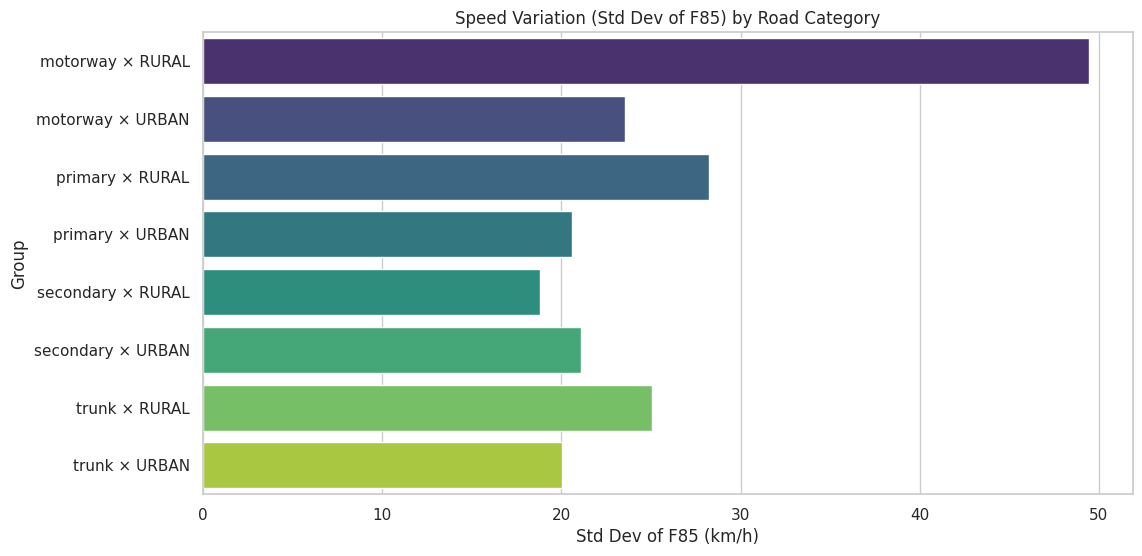

In [62]:
# SD of F85thPercentileSpeed' for each Road Group
std_data = gdf.groupby(['RoadClass', 'LandUse'])['F85thPercentileSpeed'].std().reset_index()
std_data['Group'] = std_data['RoadClass'] + ' × ' + std_data['LandUse']

plt.figure(figsize=(12, 6))
sns.barplot(data=std_data, x='F85thPercentileSpeed', y='Group', palette='viridis')
plt.title('Speed Variation (Std Dev of F85) by Road Category')
plt.xlabel('Std Dev of F85 (km/h)')
plt.show()

In [63]:
# How much the Estimated Causal Effect changes when the F85 speed changes by 1 km/h.

mean_values = {
    'primary × URBAN': 0.11288244945818704,
    'primary × RURAL': -0.19929966701581847,
    'secondary × URBAN': 0.06769778623103662,
    'secondary × RURAL': 0.15104652167377708,
    'trunk × URBAN': 0.05453340125739459,
    'trunk × RURAL': 0.023312300972122557,
    'motorway × URBAN': -0.13833191916410925,
    'motorway × RURAL': 7.105427357601002e-15
}

results = []

for group_name, mean_val in mean_values.items():
    road, land = group_name.split(' × ')
    df_group = gdf[(gdf['RoadClass'] == road) & (gdf['LandUse'] == land)]

    if not df_group.empty:
        # SD
        std_f85 = df_group['F85thPercentileSpeed'].std()

        # Impact of 1km/h reduction
        impact_per_kmh = (mean_val / std_f85) if std_f85 > 0 else 0

        results.append({
            'Road Category': group_name,
            'Model Coefficient': mean_val,
            'Speed Std Dev (std_f85)': std_f85,
            'Impact per 1km/h': impact_per_kmh
        })

df_results = pd.DataFrame(results)
pd.options.display.float_format = '{:.10f}'.format

print(df_results.to_string(index=False))

    Road Category  Model Coefficient  Speed Std Dev (std_f85)  Impact per 1km/h
  primary × URBAN       0.1128824495            20.5852919759      0.0054836458
  primary × RURAL      -0.1992996670            28.2425433552     -0.0070567181
secondary × URBAN       0.0676977862            21.1155145071      0.0032060685
secondary × RURAL       0.1510465217            18.8087410836      0.0080306556
    trunk × URBAN       0.0545334013            20.0312798543      0.0027224122
    trunk × RURAL       0.0233123010            25.0318312219      0.0009313063
 motorway × URBAN      -0.1383319192            23.5484187175     -0.0058743613
 motorway × RURAL       0.0000000000            49.4198479280      0.0000000000


In [64]:
# accident rate
gdf['accident_rate'] = gdf['accidents_2024'] / gdf['WeightedSample']
gdf['accident_rate'] = gdf['accident_rate'].fillna(0).replace([np.inf, -np.inf], 0)

# RoadCategory = RoadClass * LandUse
gdf['RoadCategory'] = gdf['RoadClass'] + ' × ' + gdf['LandUse']

# Impact calcurated from mean value from causal model
# Impact per 1km/h F85 reduction (unit: Log-risk change per km/h)  = (Model Coefficient /Standard Deviation of F85 as per Road Group)
impact_map = {
    'primary × URBAN': 0.0054836458,
    'primary × RURAL': -0.0070567181,
    'secondary × URBAN': 0.0032060685,
    'secondary × RURAL': 0.0080306556,
    'trunk × URBAN': 0.0027224122,
    'trunk × RURAL': 0.0009313063,
    'motorway × URBAN': -0.0058743613,
    'motorway × RURAL': 0.0000000000
}
gdf['Impact per 1km/h'] = gdf['RoadCategory'].map(impact_map)

# ave accident is used for the simulation only if there is no accidents for the road segments (Potential_Accident_Rate')
gdf['avg_accident_rate'] = gdf.groupby('RoadCategory')['accident_rate'].transform('mean')
gdf['Potential_Accident_Rate'] = gdf[['accident_rate', 'avg_accident_rate']].max(axis=1)

# Lives saved per year : (accident_rate *Impact per 1km/h F85 reduction * weighted_sample_size)
gdf['Lives_Saved'] = (
    gdf['Potential_Accident_Rate'] *
    gdf['Impact per 1km/h'] *
    gdf['WeightedSample']
)

def final_classify(lives_saved):
    if lives_saved <= 0:
        return 'Stable' # Stable/Further investigation required
    elif lives_saved < 0.0005:    #Monitor
        return 'Monitor'
    elif lives_saved < 0.002:    #Attention
        return 'Attention'
    else:
        return 'Critical'   # Critical

gdf['Status'] = gdf['Lives_Saved'].apply(final_classify)

print(gdf['Status'].value_counts())

Status
Monitor      8459
Stable       1637
Attention     990
Critical      458
Name: count, dtype: int64


In [65]:
print(gdf['Lives_Saved'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

count   11544.0000000000
mean        0.0003426230
std         0.0039542569
min        -0.1856844294
25%         0.0000105484
50%         0.0000513955
75%         0.0002008836
90%         0.0006632769
95%         0.0014755096
max         0.1031735281
Name: Lives_Saved, dtype: float64


In [ ]:
gdf['Lives_Saved'].describe()

,Lives_Saved
count,11544.0000000000
mean,0.0003426230
std,0.0039542569
min,-0.1856844294
25%,0.0000105484
50%,0.0000513955
75%,0.0002008836
max,0.1031735281


In [67]:
# Extract only data classified as 'Stable' (as "Further investigation required"  is also included in this category)
stable_roads = gdf[gdf['Status'] == 'Stable']

# Separate into negative impact (less than 0) and zero impact (equal to 0)
negative_impact = stable_roads[stable_roads['Lives_Saved'] < 0]
zero_impact = stable_roads[stable_roads['Lives_Saved'] == 0]

print(f"Breakdown of 'Stable' segments:")
print(f"- Negative Impact: {len(negative_impact)} segments")
print(f"- Zero Impact: {len(zero_impact)} segments")
print(f"- Total: {len(stable_roads)} segments")

# Check the breakdown by RoadCategory to identify which road types show negative impact
print("\n[Breakdown by Road Category]")
print(negative_impact['RoadCategory'].value_counts())

Breakdown of 'Stable' segments:
- Negative Impact: 1598 segments
- Zero Impact: 39 segments
- Total: 1637 segments

[Breakdown by Road Category]
RoadCategory
primary × RURAL     1485
motorway × URBAN     113
Name: count, dtype: int64


In [68]:
# scorecategories
score_map = {'Critical': 20, 'Attention': 40, 'Monitor': 60, 'Stable': 80}
gdf['Safety_Score_Plotting'] = gdf['Status'].map(score_map)

# 1. Target Speed
target_speed_map = {
    'primary × URBAN': 60,
    'primary × RURAL': 100,
    'secondary × URBAN': 30,
    'secondary × RURAL': 60,
    'motorway × URBAN': 120,
    'motorway × RURAL': 120,
    'trunk × URBAN': 60,
    'trunk × RURAL': 100
}

gdf['speed_target'] = gdf['RoadCategory'].map(target_speed_map)

if gdf['speed_target'].isnull().sum() > 0:
    print(f"Warning: {gdf['speed_target'].isnull().sum()} rows have no target speed assigned!")

columns_to_keep = [
    'OBJECTID', 'english_ro', 'OvertureID', 'SampleSize_avg', 'RoadLength',
    'WeightedSample', 'Percent_', 'Percentile', 'SpeedLimit', 'RoadClass',
    'NumberOverLimit', 'MedianSpeed', 'F85thPercentileSpeed', 'ForAnalysis',
    'ProvinceID', 'SpeedLimitFloor', 'PercentOverLimit', 'InvPercentile',
    'AnalysisStatus', 'RankedPercentile', 'StreetImageLink', 'LandUse',
    'NO_OF_Result_Segments', 'PercentileBand', 'SampleSizeTotal',
    'Shape_Length', 'non_compliance', 'accidents_2024', 'geometry',
    # added
    'accident_rate', 'RoadCategory', 'Impact per 1km/h',
    'avg_accident_rate', 'Potential_Accident_Rate', 'Lives_Saved',
    'Status', 'Safety_Score_Plotting','speed_target'
]

existing_cols = [c for c in columns_to_keep if c in gdf.columns]
gdf_final = gdf[existing_cols].copy()

output_path = 'safety_score_1.geojson'
gdf_final.to_file(output_path, driver='GeoJSON')

#print(f"--- Analysis Summary ---")
#print(gdf_final['Status'].value_counts())

In [69]:
len(gdf) #11544

11544